<a href="https://colab.research.google.com/github/milleau98/2026-gig-data-analysis/blob/main/notebooks/data-analyses/timeseries_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy matplotlib scipy seaborn

In [2]:
import os
from getpass import getpass

TOKEN = getpass('Enter GitHub token: ')
REPO = "milleau98/2026-gig-data-analysis"

if not os.path.exists("2026-gig-data-analysis"):
    !git clone https://{TOKEN}@github.com/{REPO}.git
else:
    %cd 2026-gig-data-analysis
    !git pull

Enter GitHub token: ··········
Cloning into '2026-gig-data-analysis'...
remote: Enumerating objects: 719, done.
remote: Counting objects: 100% (278/278), done.
remote: Compressing objects: 100% (230/230), done.
remote: Total 719 (delta 153), reused 76 (delta 48), pack-reused 441 (from 1)
Receiving objects: 100% (719/719), 47.72 MiB | 19.51 MiB/s, done.
Resolving deltas: 100% (344/344), done.


In [3]:
import pandas as pd

# stock price

gig_stock_df_monthly = pd.read_csv('2026-gig-data-analysis/data/yfinance/gig_yfinance_monthly.csv', parse_dates=['Date'])

sp500_stock_df_monthly = pd.read_csv('2026-gig-data-analysis/data/yfinance/sp500_yfinance_monthly.csv', parse_dates=['Date'])

# Combine gig and sp500 stock data

stock_df_monthly = pd.concat([gig_stock_df_monthly, sp500_stock_df_monthly])


# google trend data

google_df_monthly = pd.read_csv('2026-gig-data-analysis/data/google_trends/google_trends_monthly.csv', parse_dates=['date'])

# FRED data

fred_df_monthly = pd.read_csv('2026-gig-data-analysis/data/fred/fred_monthly_data.csv', parse_dates=['date'])


stock_df_monthly.head()
fred_df_monthly.head()

,date,month,quarter,year,interest_rate_mtg_data_weekly,cpi_data_monthly,cpi_fesl_data_monthly,rec_sahm_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_composite_amplitude_data_monthly,job_openings_data_monthly,job_hires_data_monthly,job_separations_data_monthly,average_weekly_earnings_data_monthly,gdp_data_quarterly,gdp_real_data_quarterly,cpi_inflation_data_annual,median_income_real_data_annual,median_income_data_annual
0,1854-12-01,12,4,1854,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1855-01-01,1,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1855-02-01,2,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1855-03-01,3,1,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1855-04-01,4,2,1855,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
google_df_monthly_long = google_df_monthly.melt(
    id_vars=['year', 'month'],
    value_vars= ['Uber','Lyft','DoorDash','Instacart','Fiverr','Upwork', 'Nu skin', 'USANA', 'side hustle','gig','Herbalife','Primerica','Etsy', 'Shopify', 'Udemy'],
    var_name = 'company',
    value_name = 'SearchInterest'
)


In [5]:
# rename columns to match across datasets
gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Year': 'year'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Year': 'year'})

stock_df_monthly = stock_df_monthly.rename(columns={'Year':'year', 'Month':'month', 'Company':'company'})

gig_stock_df_monthly = gig_stock_df_monthly.rename(columns={'Month': 'month'})
sp500_stock_df_monthly = sp500_stock_df_monthly.rename(columns={'Month': 'month'})

# only keep necessary columns before merging
monthly_stock_cols = ['year', 'month', 'company','Close']
monthly_fred_cols = ['year', 'month', 'cpi_inflation_data_annual','unemployment_data_monthly', 'cpi_data_monthly', 'rec_smooth_prob_data_monthly', 'rec_nber_data_monthly',
                     'labor_force_participation_data_monthly', 'job_hires_data_monthly', 'gdp_real_data_quarterly', 'm2_real_data_monthly', 'interest_rate_fedfunds_data_monthly',
                     'consumer_sentiment_data_monthly']

stock_df_monthly = stock_df_monthly[monthly_stock_cols]

fred_df_monthly = fred_df_monthly[monthly_fred_cols]

# Create target variable = close/cpi_data_monthly

google_df_monthly_long = google_df_monthly_long[['year', 'month', 'company','SearchInterest']]

merged_df_monthly = (
    stock_df_monthly
    .merge(google_df_monthly_long, on=['year','company','month'], how='left')
    .merge(fred_df_monthly, on=['year','month'], how='left'))

# Create target variable = close/cpi_data_monthly

merged_df_monthly['target'] = merged_df_monthly['Close'] / merged_df_monthly['cpi_data_monthly']

merged_df_monthly.head(75)

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,labor_force_participation_data_monthly,job_hires_data_monthly,gdp_real_data_quarterly,m2_real_data_monthly,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target
0,2018,10,Upwork,19.200001,1.999726,2.442583,3.8,252.772,0.46,0.0,62.9,5562.0,20304.874,5640.1,2.19,98.6,0.075958
1,2018,11,Upwork,18.629999,0.999857,2.442583,3.8,252.594,0.40,0.0,62.9,5461.0,20304.874,5654.4,2.20,97.5,0.073755
2,2018,12,Upwork,18.110001,0.999863,2.442583,3.9,252.767,0.68,0.0,63.0,5400.0,20304.874,5691.7,2.27,98.3,0.071647
3,2019,1,Upwork,19.309999,1.999740,1.812210,4.0,252.561,1.76,0.0,63.1,5411.0,20431.641,5725.2,2.40,91.2,0.076457
4,2019,2,Upwork,23.690001,1.999726,1.812210,3.8,253.319,1.82,0.0,63.1,5345.0,20431.641,5726.5,2.40,93.8,0.093518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2024,8,Upwork,9.640000,2.999516,2.949525,4.2,314.062,0.60,0.0,62.7,4846.0,23478.570,6745.7,5.33,67.9,0.030695
71,2024,9,Upwork,10.450000,1.999661,2.949525,4.1,314.732,0.68,0.0,62.7,5071.0,23478.570,6757.7,5.13,70.1,0.033203
72,2024,10,Upwork,13.560000,1.999667,2.949525,4.1,315.631,0.50,0.0,62.5,4866.0,23586.542,6758.2,4.83,70.5,0.042962
73,2024,11,Upwork,16.969999,1.999661,2.949525,4.2,316.528,0.34,0.0,62.4,4820.0,23586.542,6777.2,4.64,71.8,0.053613


In [6]:
# Create transformed variables so that we don't create spurious correlations

df = merged_df_monthly.sort_values(['company','year','month'])

# Stock returns
df['Return'] = df.groupby('company')['Close'].pct_change()
df['Target_change'] = df.groupby('company')['target'].pct_change()

# Search interest change
df['Search_change'] = df.groupby('company')['SearchInterest'].diff()

# Macro changes
df['Inflation_change'] = df['cpi_data_monthly'].pct_change()
df['Unemployment_change'] = df['unemployment_data_monthly'].diff()
df['InterestRate_change'] = df['interest_rate_fedfunds_data_monthly'].diff()
df['ConsumerSentiment_change'] = df['consumer_sentiment_data_monthly'].diff()

df.head()


/tmp/ipykernel_9068/375824016.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Target_change'] = df.groupby('company')['target'].pct_change()
/tmp/ipykernel_9068/375824016.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Inflation_change'] = df['cpi_data_monthly'].pct_change()


,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,interest_rate_fedfunds_data_monthly,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change
1526,2009,1,3M,26.811335,NaN,-0.355546,7.8,211.933,99.74,1.0,...,0.15,61.2,0.126509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1527,2009,2,3M,22.905647,NaN,-0.355546,8.3,212.705,99.36,1.0,...,0.22,56.3,0.107687,-0.145673,-0.148774,NaN,0.003643,0.5,0.07,-4.9
1528,2009,3,3M,25.052105,NaN,-0.355546,8.7,212.495,99.34,1.0,...,0.18,57.3,0.117895,0.093709,0.094790,NaN,-0.000987,0.4,-0.04,1.0
1529,2009,4,3M,29.022554,NaN,-0.355546,9.0,212.709,96.24,1.0,...,0.15,65.1,0.136443,0.158488,0.157322,NaN,0.001007,0.3,-0.03,7.8
1530,2009,5,3M,29.021479,NaN,-0.355546,9.4,213.022,87.06,1.0,...,0.18,68.7,0.136237,-0.000037,-0.001506,NaN,0.001471,0.4,0.03,3.6


In [7]:
# Create CompanyType Column to split gig/MLM and SP500 Companies
gig_companies = ['Uber','Lyft','DoorDash','Instacart','Grubhub','Fiverr','Upwork',
                 'Etsy','Shopify','Udemy',
                 ]

mlm_companies = ['Herbalife','Primerica','Tupperware','Avon','Nu skin', 'USANA']

def company_type(company):
    if company in gig_companies:
        return 'Gig'
    elif company in mlm_companies:
        return 'MLM'
    else:
        return 'SP500'

df['CompanyType'] = df['company'].apply(company_type)


df.head()

,year,month,company,Close,SearchInterest,cpi_inflation_data_annual,unemployment_data_monthly,cpi_data_monthly,rec_smooth_prob_data_monthly,rec_nber_data_monthly,...,consumer_sentiment_data_monthly,target,Return,Target_change,Search_change,Inflation_change,Unemployment_change,InterestRate_change,ConsumerSentiment_change,CompanyType
1526,2009,1,3M,26.811335,NaN,-0.355546,7.8,211.933,99.74,1.0,...,61.2,0.126509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SP500
1527,2009,2,3M,22.905647,NaN,-0.355546,8.3,212.705,99.36,1.0,...,56.3,0.107687,-0.145673,-0.148774,NaN,0.003643,0.5,0.07,-4.9,SP500
1528,2009,3,3M,25.052105,NaN,-0.355546,8.7,212.495,99.34,1.0,...,57.3,0.117895,0.093709,0.094790,NaN,-0.000987,0.4,-0.04,1.0,SP500
1529,2009,4,3M,29.022554,NaN,-0.355546,9.0,212.709,96.24,1.0,...,65.1,0.136443,0.158488,0.157322,NaN,0.001007,0.3,-0.03,7.8,SP500
1530,2009,5,3M,29.021479,NaN,-0.355546,9.4,213.022,87.06,1.0,...,68.7,0.136237,-0.000037,-0.001506,NaN,0.001471,0.4,0.03,3.6,SP500


In [8]:
time_series_df = df.groupby(['year', 'month']).agg({
    'Close':'mean',
    'SearchInterest': 'mean',
    'unemployment_data_monthly' : 'mean',
    'cpi_data_monthly': 'mean',
}).reset_index()

time_series_df.head()

,year,month,Close,SearchInterest,unemployment_data_monthly,cpi_data_monthly
0,2009,1,17.326055,1.492537,7.8,211.933
1,2009,2,15.273790,1.492537,8.3,212.705
2,2009,3,16.867928,1.492537,8.7,212.495
3,2009,4,19.141466,1.492537,9.0,212.709
4,2009,5,19.817351,1.990050,9.4,213.022


In [9]:
gig_ts = df[df['CompanyType'] == 'Gig'].groupby(['year','month']).agg({
    'Close':'mean',
    'SearchInterest':'mean'
}).reset_index()

mlm_ts = df[df['CompanyType'] == 'MLM'].groupby(['year','month']).agg({
    'Close':'mean',
    'SearchInterest':'mean'
}).reset_index()

sp_ts = df[df['CompanyType'] == 'SP500'].groupby(['year','month']).agg({
    'Close':'mean'
}).reset_index()

gig_ts.head()

,year,month,Close,SearchInterest
0,2015,4,22.2400,53.095086
1,2015,5,9.7400,28.053323
2,2015,6,8.7225,25.843077
3,2015,7,12.2895,27.866473
4,2015,8,8.5420,29.429602


In [10]:
macro_ts = df.groupby(['year','month']).agg({
    'unemployment_data_monthly':'mean',
    'cpi_data_monthly':'mean'
}).reset_index()

macro_ts.head()

,year,month,unemployment_data_monthly,cpi_data_monthly
0,2009,1,7.8,211.933
1,2009,2,8.3,212.705
2,2009,3,8.7,212.495
3,2009,4,9.0,212.709
4,2009,5,9.4,213.022


In [11]:
sp_ts = sp_ts.add_suffix('_SP')
sp_ts = sp_ts.rename(columns={'year_SP': 'year', 'month_SP': 'month'})

ts = gig_ts.merge(mlm_ts, on=['year','month'], suffixes=('_Gig','_MLM'))
ts = ts.merge(sp_ts, on=['year', 'month'], suffixes=('', '_SP'))
ts = ts.merge(macro_ts, on=['year','month'])

ts

,year,month,Close_Gig,SearchInterest_Gig,Close_MLM,SearchInterest_MLM,Close_SP,unemployment_data_monthly,cpi_data_monthly
0,2015,4,22.240000,53.095086,39.252428,2.999375,58.950044,5.4,236.222
1,2015,5,9.740000,28.053323,42.864629,2.999434,60.214428,5.6,237.001
2,2015,6,8.722500,25.843077,45.226955,2.666230,59.303512,5.3,237.657
3,2015,7,12.289500,27.866473,42.325033,2.999531,60.604780,5.2,238.034
4,2015,8,8.542000,29.429602,46.394672,2.999524,57.592347,5.1,238.033
...,...,...,...,...,...,...,...,...,...
124,2025,8,73.243000,29.937475,102.908904,1.666425,215.425817,4.3,323.291
125,2025,9,79.168999,27.947799,103.735385,0.999841,218.539587,4.4,324.245
126,2025,10,78.482499,28.836775,95.599235,0.999846,215.605598,NaN,NaN
127,2025,11,69.510000,31.418447,96.239303,1.333137,219.856629,4.5,325.063


In [12]:
ts['time'] = ts['year'].astype(str) + ' M' + ts['month'].astype(str)
ts

,year,month,Close_Gig,SearchInterest_Gig,Close_MLM,SearchInterest_MLM,Close_SP,unemployment_data_monthly,cpi_data_monthly,time
0,2015,4,22.240000,53.095086,39.252428,2.999375,58.950044,5.4,236.222,2015 M4
1,2015,5,9.740000,28.053323,42.864629,2.999434,60.214428,5.6,237.001,2015 M5
2,2015,6,8.722500,25.843077,45.226955,2.666230,59.303512,5.3,237.657,2015 M6
3,2015,7,12.289500,27.866473,42.325033,2.999531,60.604780,5.2,238.034,2015 M7
4,2015,8,8.542000,29.429602,46.394672,2.999524,57.592347,5.1,238.033,2015 M8
...,...,...,...,...,...,...,...,...,...,...
124,2025,8,73.243000,29.937475,102.908904,1.666425,215.425817,4.3,323.291,2025 M8
125,2025,9,79.168999,27.947799,103.735385,0.999841,218.539587,4.4,324.245,2025 M9
126,2025,10,78.482499,28.836775,95.599235,0.999846,215.605598,NaN,NaN,2025 M10
127,2025,11,69.510000,31.418447,96.239303,1.333137,219.856629,4.5,325.063,2025 M11


In [13]:
# Normalize variables

ts['Gig_norm'] = ts['Close_Gig'] / ts['Close_Gig'].dropna().iloc[0]
ts['MLM_norm'] = ts['Close_MLM'] / ts['Close_MLM'].dropna().iloc[0]
ts['SP_norm'] = ts['Close_SP'] / ts['Close_SP'].dropna().iloc[0]
ts['Gig_Search_norm'] = ts['SearchInterest_Gig'] / ts['SearchInterest_Gig'].iloc[0]
ts['MLM_Search_norm'] = ts['SearchInterest_MLM'] / ts['SearchInterest_MLM'].iloc[0]
ts['Unemployment_norm'] = ts['unemployment_data_monthly'] / ts['unemployment_data_monthly'].iloc[0]
ts['CPI_norm'] = ts['cpi_data_monthly'] / ts['cpi_data_monthly'].iloc[0]

ts

,year,month,Close_Gig,SearchInterest_Gig,Close_MLM,SearchInterest_MLM,Close_SP,unemployment_data_monthly,cpi_data_monthly,time,Gig_norm,MLM_norm,SP_norm,Gig_Search_norm,MLM_Search_norm,Unemployment_norm,CPI_norm
0,2015,4,22.240000,53.095086,39.252428,2.999375,58.950044,5.4,236.222,2015 M4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2015,5,9.740000,28.053323,42.864629,2.999434,60.214428,5.6,237.001,2015 M5,0.437950,1.092025,1.021448,0.528360,1.000020,1.037037,1.003298
2,2015,6,8.722500,25.843077,45.226955,2.666230,59.303512,5.3,237.657,2015 M6,0.392199,1.152208,1.005996,0.486732,0.888928,0.981481,1.006075
3,2015,7,12.289500,27.866473,42.325033,2.999531,60.604780,5.2,238.034,2015 M7,0.552585,1.078278,1.028070,0.524841,1.000052,0.962963,1.007671
4,2015,8,8.542000,29.429602,46.394672,2.999524,57.592347,5.1,238.033,2015 M8,0.384083,1.181957,0.976969,0.554281,1.000050,0.944444,1.007667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,2025,8,73.243000,29.937475,102.908904,1.666425,215.425817,4.3,323.291,2025 M8,3.293300,2.621721,3.654379,0.563846,0.555591,0.796296,1.368590
125,2025,9,79.168999,27.947799,103.735385,0.999841,218.539587,4.4,324.245,2025 M9,3.559757,2.642776,3.707200,0.526373,0.333350,0.814815,1.372628
126,2025,10,78.482499,28.836775,95.599235,0.999846,215.605598,NaN,NaN,2025 M10,3.528889,2.435499,3.657429,0.543116,0.333351,NaN,NaN
127,2025,11,69.510000,31.418447,96.239303,1.333137,219.856629,4.5,325.063,2025 M11,3.125450,2.451805,3.729541,0.591739,0.444472,0.833333,1.376091


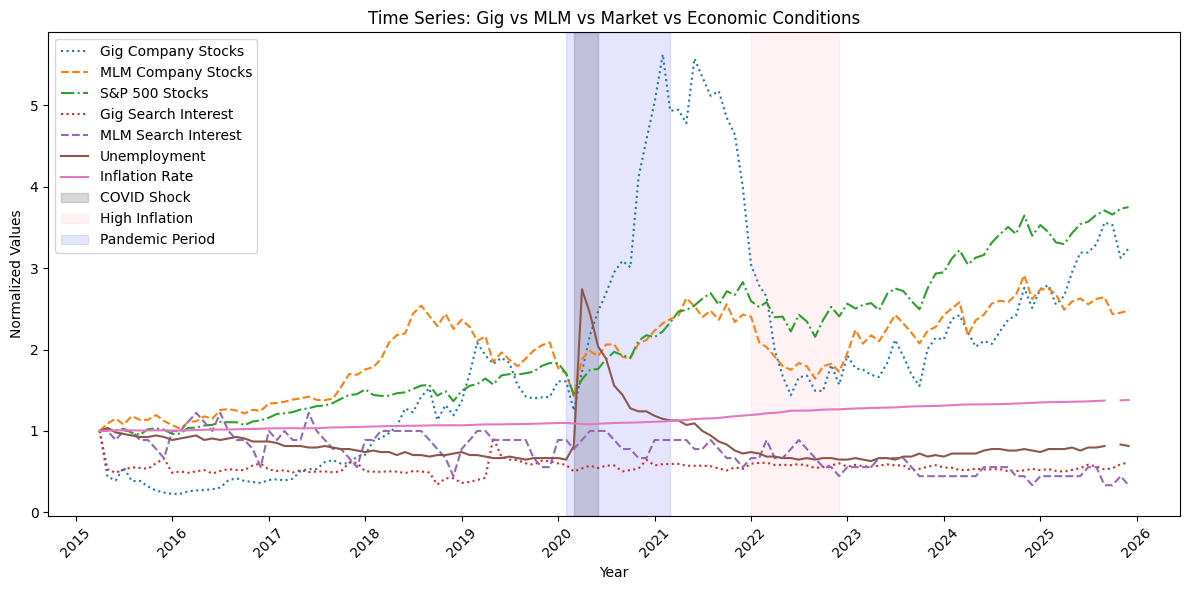

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Make sure you have a datetime column
ts['date'] = pd.to_datetime(ts[['year', 'month']].assign(day=1))  # first day of each month

plt.figure(figsize=(12,6))

plt.plot(ts['date'], ts['Gig_norm'], label='Gig Company Stocks', linestyle=':')
plt.plot(ts['date'], ts['MLM_norm'], label='MLM Company Stocks', linestyle='--')
plt.plot(ts['date'], ts['SP_norm'], label='S&P 500 Stocks', linestyle='-.')
plt.plot(ts['date'], ts['Gig_Search_norm'], label='Gig Search Interest', linestyle=':')
plt.plot(ts['date'], ts['MLM_Search_norm'], label='MLM Search Interest', linestyle='--')
plt.plot(ts['date'], ts['Unemployment_norm'], label='Unemployment', linestyle='-')
plt.plot(ts['date'], ts['CPI_norm'], label='Inflation Rate', linestyle='-')

# Format x-axis to show only every year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # major ticks every year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # show only year

ax = plt.gca()

# COVID shock (example: Mar 2020 – Jun 2020)
ax.axvspan(pd.to_datetime('2020-03-01'),
           pd.to_datetime('2020-06-01'),
           color='gray', alpha=0.3, label='COVID Shock')

# Inflation spike (example: Jan 2022 – Dec 2022)
ax.axvspan(pd.to_datetime('2022-01-01'),
           pd.to_datetime('2022-12-01'),
           color='pink', alpha=0.2, label='High Inflation')

# Optional: multiple smaller shocks
ax.axvspan(pd.to_datetime('2020-02-01'),
           pd.to_datetime('2021-03-01'),
           color='blue', alpha=0.1, label='Pandemic Period')

plt.legend()
plt.title('Time Series: Gig vs MLM vs Market vs Economic Conditions')
plt.xlabel('Year')
plt.ylabel('Normalized Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

